# Isotropic–Nematic Phase Transition in Liquid Crystals

Some materials consisting of strongly anisotropic colloids or molecules behave as liquid crystals. Liquid crystals possess many of the mechanical properties of a liquid, such as high fluidity, but are similar to crystals in other physical properties. For example, they may be birefringent and may have anisotropic magnetic or electric susceptibilities.

Liquid crystals often exhibit a transition between the crystalline phase and the isotropic liquid phase as a function of the temperature or the concentration. In this exercise, we will study a temperature-induced phase transition.

Consider a two-dimensional square grid of anisotropic molecules, each characterized by a unit vector $\mathbf{u}$. The molecules $i$ and $j$ interact via the potential

$$
U(r, \mathbf{u}^{(i)}, \mathbf{u}^{(j)}) = -\varepsilon(r)\, \big(\mathbf{u}^{(i)} \cdot \mathbf{u}^{(j)}\big)^2.
$$

The function $\varepsilon(r)$ depends on the distance $r$ between the molecules. We do not consider the fluidity of the system, keeping the molecule positions fixed instead.


## 1. Monte Carlo Sampling

### (a)

Generate a $10 \times 10$ grid of unit vectors and write a script that selects a molecule and rotates its unit vector over an arbitrary angle $0 < \phi < 2\pi$.

Does this transition satisfy detailed balance?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
N = 10
#create random angles
theta = 2*np.pi*np.random.rand(N,N)
#unitvectors
u_x = np.cos(theta)
u_y = np.sin(theta)



Zusätzlich Vectorfeld Ploten

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


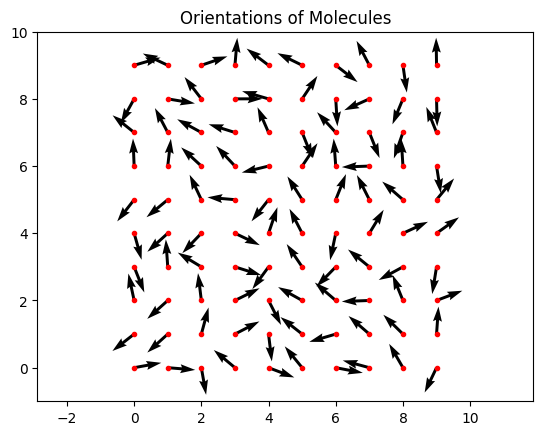

In [2]:
# Gitterpunkte
X, Y = np.meshgrid(np.arange(N), np.arange(N))

# Plot as Vectorfeld
plt.figure()
plt.quiver(X, Y, u_x, u_y)
plt.plot(X,Y,'r.')
plt.title("Orientations of Molecules")
plt.axis("equal")
plt.xlim(-1, N)
plt.ylim(-1, N)
plt.show()

Define nessesary Functions

In [ ]:

#This function calculates the Potential energy between 2 Particles
#This function is not needet for the vectorized option
def E_pot_two_particles(theta1,theta2,eps=1.0):
    return -eps*np.cos(theta1-theta2)**2

#Calc whole energy of the System (loop variant)
def calc_E_tot_l(theta, eps=1.0):
    N = theta.shape[0]
    E = 0.0
    for i in range(N):
        for j in range(N):
            # right neighbour
            E += E_pot_two_particles(theta[i, j], theta[i, (j + 1) % N], eps)

            # down neighbour
            E += E_pot_two_particles(theta[i, j], theta[(i + 1) % N, j], eps)

    return E


################################################################################


#Calc whole energy of the System (vectorized variant)
def calc_E_tot_v(theta, eps=1.0):
    # to calc the interaction with every neighbor ond avoid double counting
    # use only right neigbours and neigbours below
    right = np.roll(theta,-1,axis=1)
    below = np.roll(theta,-1,axis=0)
    E = -eps*np.sum(np.cos(theta-right)**2 + np.cos(theta-below)**2)
    return E

#################################################################################

#Calc the local energy with respect to the four neigbours
def calc_E_loc(theta, i, j, eps= 1.0):
    N = theta.shape[0]
    theta_loc = theta[i,j] #vector for later calculations

    # get the neigbors -> for periodic boundary conditions use Modulo 
    neighbours = np.array([theta[(i+1)%N,j],theta[(i-1)%N,j],
                           theta[i,(j+1)%N],theta[i,(j-1)%N]])

    # summ of the 4 potential energys
    return np.sum(-eps*(np.cos(theta_loc - neighbours))**2)


### (b)

Write a Monte Carlo script that simulates a $10 \times 10$ grid of freely rotating molecules interacting only with their nearest neighbours via the potential of Eq. (1).

That means that each molecule only interacts with the four molecules on the adjacent grid points in the two perpendicular directions of the square grid. In terms of the interaction potential of Eq. (1), the function $\varepsilon(r)$ is a step function, equal to $\varepsilon$ for nearest neighbours and zero otherwise.

Use periodic boundary conditions.

In [4]:
#test feld
#Lecture Script: 1.3.9
#1st step -> choose any starting configuration
#test = np.arange(1,N**2 + 1).reshape(N,N)
#print(test)
#test2 = np.roll(test,-1,axis=0)
#print(test2)
#compar the two endergy calculation
E_vec = calc_E_tot_v(theta,1.0)
E_loop = calc_E_tot_l(theta,1.0)
print("E vectorisiert berechnet = ",E_vec)
print("E with loop berechnet = ", E_loop)

E vectorisiert berechnet =  -110.1634772996417
E with loop berechnet =  -110.16347729964166


In [5]:
# Here start with Montecarlo
N_steps = 1000
T = 0.5
for step in range(N_steps):
    i = np.random.randint(0,N)
    j = np.random.randint(0,N)
    #remember old theta
    theta_old = theta[i,j]
    #generate the new one
    theta_new = np.random.rand()*2*np.pi #is equivalent to random rotation
    #calca old local energy
    E_loc_old = calc_E_loc(theta,i,j, eps= 1.0)
    #calc new local energy 
    theta[i,j] = theta_new
    E_loc_new = calc_E_loc(theta,i,j, eps= 1.0)
    #print(E_loc_old)
    #print(E_loc_new)
    delta_E = E_loc_new - E_loc_old
    if (delta_E > 0) and (np.random.rand() > np.exp(-delta_E/T)):
        theta[i, j] = theta_old


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


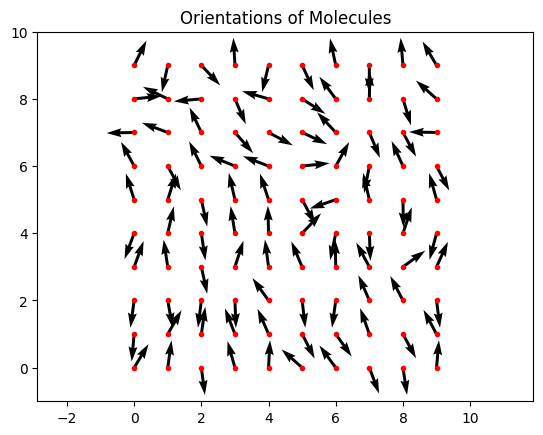

In [6]:
#test field to check the result
# Gitterpunkte
X, Y = np.meshgrid(np.arange(N), np.arange(N))
u_x = np.cos(theta)
u_y = np.sin(theta)
# Plot as Vectorfeld
plt.figure()
plt.quiver(X, Y, u_x, u_y)
plt.plot(X,Y,'r.')
plt.title("Orientations of Molecules")
plt.axis("equal")
plt.xlim(-1, N)
plt.ylim(-1, N)
plt.show()

### (c)

In order to extract meaningful results, run the Monte Carlo algorithm for a number of equilibration steps before starting the production run used for generating a sample.

After the equilibration, the system should have converged to a stable configuration. To check for convergence, calculate the interaction energy of the entire grid and plot the result as a function of Monte Carlo steps.

Determine the number of necessary equilibration steps by eye.

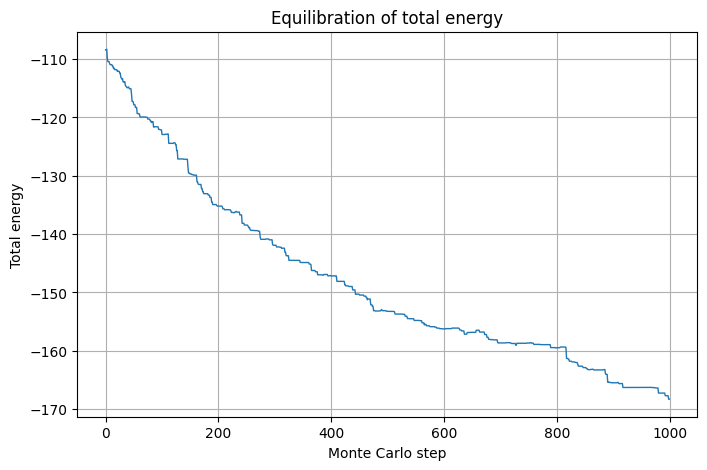

In [30]:
# Parameter
N = 10
eps = 1.0
T = 0.1
N_steps = 1000

# new random starting angles
theta = 2 * np.pi * np.random.rand(N, N)

# Liste für die Gesamtenergie
E_hist = np.empty(N_steps)

for step in range(N_steps):
    i = np.random.randint(0,N)
    j = np.random.randint(0,N)
    #remember old theta
    theta_old = theta[i,j]
    #generate the new one
    theta_new = np.random.uniform(0.0, 2.0 * np.pi) #is equivalent to random rotation
    #calca old local energy
    E_loc_old = calc_E_loc(theta,i,j, eps= 1.0)
    #calc new local energy 
    theta[i,j] = theta_new
    E_loc_new = calc_E_loc(theta,i,j, eps= 1.0)
    #print(E_loc_old)
    #print(E_loc_new)
    delta_E = E_loc_new - E_loc_old
    if delta_E > 0 and np.random.rand() >  np.exp(-delta_E/T):
        theta[i, j] = theta_old

    #safe E-tot for the histogramm
    E_hist[step] = calc_E_tot_l(theta, eps=eps)

# Plot
plt.figure(figsize=(8,5))
plt.plot(E_hist, lw=1)
plt.xlabel("Monte Carlo step")
plt.ylabel("Total energy")
plt.title("Equilibration of total energy")
plt.grid(True)
plt.show()

## 2. Order parameter

The elements of the two-dimensional nematic order tensor are defined as

$
Q_{\alpha\beta} = \frac{1}{N} \sum_{i=1}^{N} \left( 2 u_{\alpha}^{(i)} u_{\beta}^{(i)} - \delta_{\alpha\beta} \right),
$

where $N$ is the number of molecules, $u_{\alpha}^{(i)}\) and (\u_{\beta}^{(i)}\$ are the components of the orientation vector of molecule \(i\), and \(\delta_{\alpha\beta}\) is the Kronecker delta.

The largest eigenvalue of this tensor corresponds to the nematic order parameter \(S\), which can also be written as

$
S = \frac{1}{N} \sum_{i=1}^{N} \left( 2\cos^2\psi_i - 1 \right),
$

where \(\psi_i\) is the angle between the orientation of molecule \(i\) and the generally unknown nematic director.

From this expression, it follows that \(S \to 1\) when all molecules are perfectly aligned with the director. In contrast, \(S \to 0\) in the isotropic phase, where the molecular orientations are randomly distributed.

## (a)

Write a script to calculate the tensor $Q$ and the order parameter $S$ at every Monte Carlo step from Eq. (2).  
Calculate the distribution of the order parameter $S$ over a large number of Monte Carlo steps.  
Plot the corresponding histogram both for a temperature $k_B T \ll \varepsilon$ and for a temperature $k_B T \gg \varepsilon$.  
Add error bars to the plots according to the Bayesian approach with a flat prior.

In [8]:
# determine Q and S
def determine_Q_S(theta):
    N = theta.size
    # x and y component of U 
    u_x = np.cos(theta)
    u_y = np.sin(theta)

    # calc Q_ij as given in formula 2 
    Q_xx  = np.sum(2*u_x*u_x - 1) / N
    Q_yy  = np.sum(2*u_y*u_y - 1) / N
    # Q_xy = Q_yx
    Q_xy = np.sum(2*u_x*u_y) / N

    # Built the matrix
    Q = np.matrix([[Q_xx,Q_xy],
                  [Q_xy,Q_yy]])
    
    #calc eigenvalues of Q 
    ev = np.linalg.eigvals(Q)
    #get the largest eingenvale for S 
    S = np.max(ev)

    return Q,S

#Q_test, S_test = determine_Q_S(theta)
#print("Q =")
#print(Q_test)
#print("S =", S_test)

Last Q:
[[-0.36561286 -0.51349676]
 [-0.51349676  0.36561286]]
Last S: 0.6303583744309351


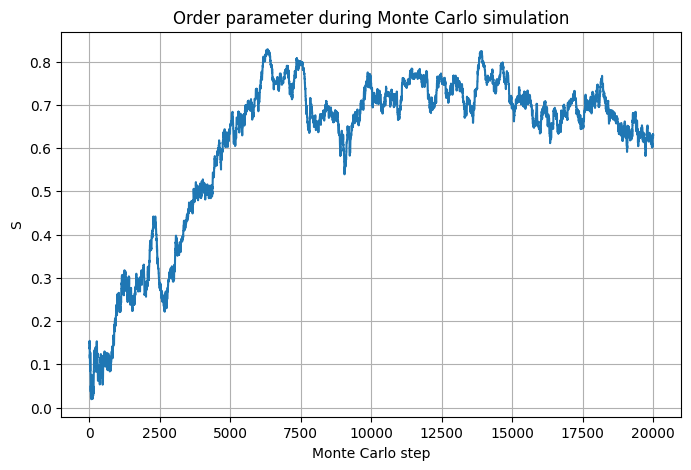

In [9]:
# Parameter
N = 10
eps = 1.0
T = 0.5
N_steps = 20000

# new random starting angles
theta = 2 * np.pi * np.random.rand(N, N)

# Liste für die Gesamtenergie
E_hist = np.empty(N_steps)

# Liste für den order parameter
S_hist = np.empty(N_steps)

for step in range(N_steps):
    i = np.random.randint(0, N)
    j = np.random.randint(0, N)

    # remember old theta
    theta_old = theta[i, j]

    # generate the new one
    theta_new = np.random.rand() * 2 * np.pi   # equivalent to random rotation

    # calc old local energy
    E_loc_old = calc_E_loc(theta, i, j, eps=eps)

    # calc new local energy
    theta[i, j] = theta_new
    E_loc_new = calc_E_loc(theta, i, j, eps=eps)

    delta_E = E_loc_new - E_loc_old

    if delta_E > 0 and np.random.rand() > np.exp(-delta_E / T):
        theta[i, j] = theta_old

    E_hist[step] = calc_E_tot_l(theta, eps=eps)

    # calculate Q and S and save S
    Q, S = determine_Q_S(theta)
    S_hist[step] = S


print("Last Q:")
print(Q)
print("Last S:", S)

plt.figure(figsize=(8,5))
plt.plot(S_hist)
plt.xlabel("Monte Carlo step")
plt.ylabel("S")
plt.title("Order parameter during Monte Carlo simulation")
plt.grid(True)
plt.show()